<a href="https://colab.research.google.com/github/selenakdik/bitki-sagligi-teshisi/blob/main/Bitki_Hastalik_V3_G%C3%BCr%C3%BClt%C3%BCl%C3%BC_E%C4%9Fitim.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [2]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [3]:
!unzip -q "/content/drive/MyDrive/veriseti3.zip" -d "/content/dataset_v3"

In [4]:
import os
print("Ana klasörler:", os.listdir('/content/dataset_v3'))

Ana klasörler: ['veriseti3']


In [5]:
import os
base_path = '/content/dataset_v3/veriseti3'

# Klasörleri (sınıfları) listele ve alfabetik sırala
classes = sorted(os.listdir(base_path))

print(f"Veri Setindeki Toplam Sınıf Sayısı: {len(classes)}\n")
print(f"{'Hastalık Adı':<50} | {'Fotoğraf Sayısı'}")
print("-" * 70)

total_images = 0
for cls in classes:
    # Her bir hastalık klasörünün yolunu oluştur
    class_path = os.path.join(base_path, cls)

    # Klasör içindeki dosyaları listele (sadece dosya olanları sayar)
    num_images = len([f for f in os.listdir(class_path) if os.path.isfile(os.path.join(class_path, f))])

    total_images += num_images
    print(f"{cls:<50} | {num_images}")

print("-" * 70)
print(f"Veri Seti Toplam Fotoğraf Sayısı: {total_images}")


Veri Setindeki Toplam Sınıf Sayısı: 17

Hastalık Adı                                       | Fotoğraf Sayısı
----------------------------------------------------------------------
Apple___Apple_scab                                 | 630
Apple___Black_rot                                  | 621
Apple___Cedar_apple_rust                           | 275
Apple___healthy                                    | 1645
Potato___Early_blight                              | 1000
Potato___Late_blight                               | 1000
Potato___healthy                                   | 152
Tomato___Bacterial_spot                            | 2127
Tomato___Early_blight                              | 1000
Tomato___Late_blight                               | 1909
Tomato___Leaf_Mold                                 | 952
Tomato___Septoria_leaf_spot                        | 1771
Tomato___Spider_mites Two-spotted_spider_mite      | 1676
Tomato___Target_Spot                               | 1404
Tomato___Toma

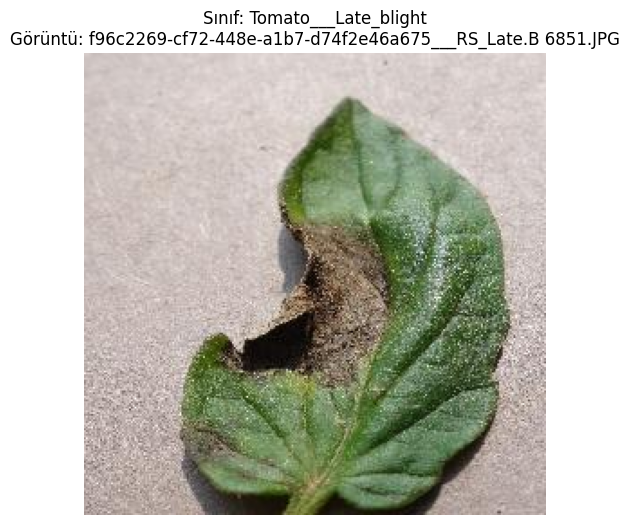

Görselin boyutu: (256, 256, 3)


In [6]:
import matplotlib.pyplot as plt
import matplotlib.image as mpimg
import random
import os

base_path = '/content/dataset_v3/veriseti3'

# Mevcut sınıflar arasından rastgele bir sınıf seçme
random_class = random.choice(classes)
class_path = os.path.join(base_path, random_class)

# O sınıftan rastgele bir fotoğraf seçme
random_image = random.choice(os.listdir(class_path))
image_path = os.path.join(class_path, random_image)

# Görseli oku ve ekrana bas
img = mpimg.imread(image_path)
plt.figure(figsize=(8, 6))
plt.imshow(img)
plt.title(f"Sınıf: {random_class}\nGörüntü: {random_image}")
plt.axis('off')
plt.show()

print(f"Görselin boyutu: {img.shape}")

In [7]:
import tensorflow as tf
from tensorflow.keras import layers

# --- VERİ ARTIRMA KATMANI ---
data_augmentation = tf.keras.Sequential([
    # 1. Geometrik İşlemler
    layers.RandomFlip("horizontal_and_vertical"),
    layers.RandomRotation(0.2),
    layers.RandomZoom(0.1),
    layers.RandomTranslation(height_factor=0.1, width_factor=0.1),

    # 2. Işık ve Renk Gürültüsü
    layers.RandomBrightness(factor=0.2),
    layers.RandomContrast(factor=0.2),

    # 3. Gauss Gürültüsü
    layers.GaussianNoise(0.1),

    # 4. Bulanıklık Simülasyonu
    # Bu katman görüntüyü hafifçe bulanıklaştırarak odak kaybını taklit eder.
    layers.AveragePooling2D(pool_size=(3, 3), strides=(1, 1), padding='same')
])

In [8]:
# Görüntü boyutlarını ve paket miktarını (batch) belirleme
IMAGE_SIZE = (256, 256)
BATCH_SIZE = 32

# Yeni veri yolun (veriseti3 içindeki elma, domates, patates klasörleri)
base_path = '/content/dataset_v3/veriseti3'

# Eğitim verileri (%80)
train_ds = tf.keras.utils.image_dataset_from_directory(
    base_path,
    validation_split=0.2,
    subset="training",
    seed=123,
    image_size=IMAGE_SIZE,
    batch_size=BATCH_SIZE
)

# Doğrulama verileri (%20)
val_ds = tf.keras.utils.image_dataset_from_directory(
    base_path,
    validation_split=0.2,
    subset="validation",
    seed=123,
    image_size=IMAGE_SIZE,
    batch_size=BATCH_SIZE
)


Found 23483 files belonging to 17 classes.
Using 18787 files for training.
Found 23483 files belonging to 17 classes.
Using 4696 files for validation.


In [9]:
import numpy as np
import os

# 1. Sınıf isimlerini veri yükleyicimizden alıyoruz
class_names = train_ds.class_names
n_classes = len(class_names)

# 2. Veri setindeki toplam fotoğraf sayısını dinamik olarak hesaplama
total_images = 0
for name in class_names:
    total_images += len(os.listdir(os.path.join(base_path, name)))

# 3. Her sınıfın ağırlığını hesaplama
class_weights = {}

for i, name in enumerate(class_names):
    # O sınıfın klasöründeki güncel dosya sayısını bul
    class_count = len(os.listdir(os.path.join(base_path, name)))

    # Formül: Toplam / (Sınıf Sayısı * Sınıftaki Veri Sayısı)
    # Bu sayede veri seti dengelenmiş olur.
    weight = total_images / (n_classes * class_count)
    class_weights[i] = weight

print(f"Toplam {total_images} fotoğraf ve {n_classes} sınıf üzerinden ağırlıklar hesaplandı! ✅")

# Kontrol için ilk 3 sınıfın ağırlığını yazdıralım:
for i in range(min(3, n_classes)):
    print(f"{class_names[i]}: {class_weights[i]:.2f}")

Toplam 23483 fotoğraf ve 17 sınıf üzerinden ağırlıklar hesaplandı! ✅
Apple___Apple_scab: 2.19
Apple___Black_rot: 2.22
Apple___Cedar_apple_rust: 5.02


In [10]:
import tensorflow as tf

# HİPERPARAMETRE: Öğrenme hızı ayarı
ogrenme_hizi = 0.001
optimizasyon_araci = tf.keras.optimizers.Adam(learning_rate=ogrenme_hizi)

# EARLYSTOPPING
erken_durdurma = tf.keras.callbacks.EarlyStopping(
    monitor='val_loss',
    patience=5,
    restore_best_weights=True,
    verbose=1
)

print(f"EarlyStopping (Patience=5) ve Hiperparametre (LR={ogrenme_hizi}) başarıyla tanımlandı! ✅")

EarlyStopping (Patience=5) ve Hiperparametre (LR=0.001) başarıyla tanımlandı! ✅


In [11]:
import tensorflow as tf
from tensorflow.keras import layers, models

# 1. Sınıf sayısını dinamik olarak alıyoruz (Elma, Domates, Patates alt sınıfları)
n_classes = len(train_ds.class_names)

# 2. Yeni Model Mimarisini Oluşturalım
model = models.Sequential([

    data_augmentation,

    # Görüntü piksellerini normalize etme [0, 1]
    layers.Rescaling(1./255),

    # 1. Evrişim Bloğu
    layers.Conv2D(32, (3, 3), activation='relu', input_shape=(256, 256, 3)),
    layers.MaxPooling2D((2, 2)),

    # 2. Evrişim Bloğu
    layers.Conv2D(64, (3, 3), activation='relu'),
    layers.MaxPooling2D((2, 2)),

    # 3. Evrişim Bloğu
    layers.Conv2D(128, (3, 3), activation='relu'),
    layers.MaxPooling2D((2, 2)),

    # 4. Evrişim Bloğu
    layers.Conv2D(256, (3, 3), activation='relu'),
    layers.MaxPooling2D((2, 2)),

    # Sınıflandırma Katmanları
    layers.Flatten(),
    layers.Dense(128, activation='relu'), # 128 nöronlu tam bağlantılı katman

    # Aşırı öğrenmeyi (Overfitting) engellemek için Dropout
    layers.Dropout(0.5),

    # Çıkış Katmanı
    layers.Dense(n_classes, activation='softmax')
])

# 3. Modeli Derleme
model.compile(
    optimizer=optimizasyon_araci,
    loss=tf.keras.losses.SparseCategoricalCrossentropy(),
    metrics=['accuracy']
)

print(f"Model {n_classes} sınıf için başarıyla derlendi! ✅")


Model 17 sınıf için başarıyla derlendi! ✅


/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [12]:
# Eğitimi başlatma
history = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=100,
    callbacks=[erken_durdurma],
    class_weight=class_weights
)

Epoch 1/100
588/588 ━━━━━━━━━━━━━━━━━━━━ 59s 83ms/step - accuracy: 0.2128 - loss: 2.5770 - val_accuracy: 0.3543 - val_loss: 2.0713
Epoch 2/100
588/588 ━━━━━━━━━━━━━━━━━━━━ 51s 86ms/step - accuracy: 0.3629 - loss: 2.1022 - val_accuracy: 0.5036 - val_loss: 1.6044
Epoch 3/100
588/588 ━━━━━━━━━━━━━━━━━━━━ 50s 85ms/step - accuracy: 0.4501 - loss: 1.8011 - val_accuracy: 0.5486 - val_loss: 1.3977
Epoch 4/100
588/588 ━━━━━━━━━━━━━━━━━━━━ 49s 82ms/step - accuracy: 0.5047 - loss: 1.5834 - val_accuracy: 0.6565 - val_loss: 1.0743
Epoch 5/100
588/588 ━━━━━━━━━━━━━━━━━━━━ 49s 83ms/step - accuracy: 0.5609 - loss: 1.3888 - val_accuracy: 0.7187 - val_loss: 0.8938
Epoch 6/100
588/588 ━━━━━━━━━━━━━━━━━━━━ 50s 86ms/step - accuracy: 0.5912 - loss: 1.2785 - val_accuracy: 0.7413 - val_loss: 0.8229
Epoch 7/100
588/588 ━━━━━━━━━━━━━━━━━━━━ 50s 84ms/step - accuracy: 0.6176 - loss: 1.2048 - val_accuracy: 0.7553 - val_loss: 0.7718
Epoch 8/100
588/588 ━━━━━━━━━━━━━━━━━━━━ 83s 87ms/step - accuracy: 0.6468 - loss: 1

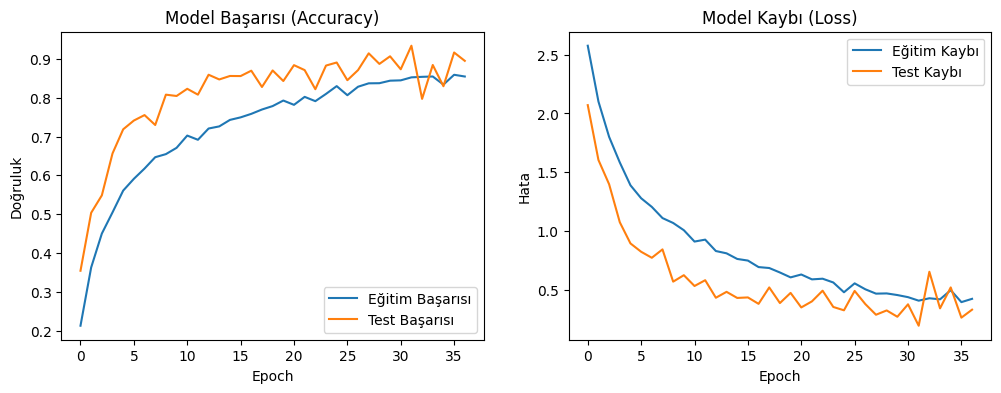

In [13]:
import matplotlib.pyplot as plt

# Doğruluk (Accuracy) Grafiği
plt.figure(figsize=(12, 4))
plt.subplot(1, 2, 1)
plt.plot(history.history['accuracy'], label='Eğitim Başarısı')
plt.plot(history.history['val_accuracy'], label='Test Başarısı')
plt.title('Model Başarısı (Accuracy)')
plt.xlabel('Epoch')
plt.ylabel('Doğruluk')
plt.legend()

# Kayıp (Loss) Grafiği
plt.subplot(1, 2, 2)
plt.plot(history.history['loss'], label='Eğitim Kaybı')
plt.plot(history.history['val_loss'], label='Test Kaybı')
plt.title('Model Kaybı (Loss)')
plt.xlabel('Epoch')
plt.ylabel('Hata')
plt.legend()

plt.show()

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 74ms/step


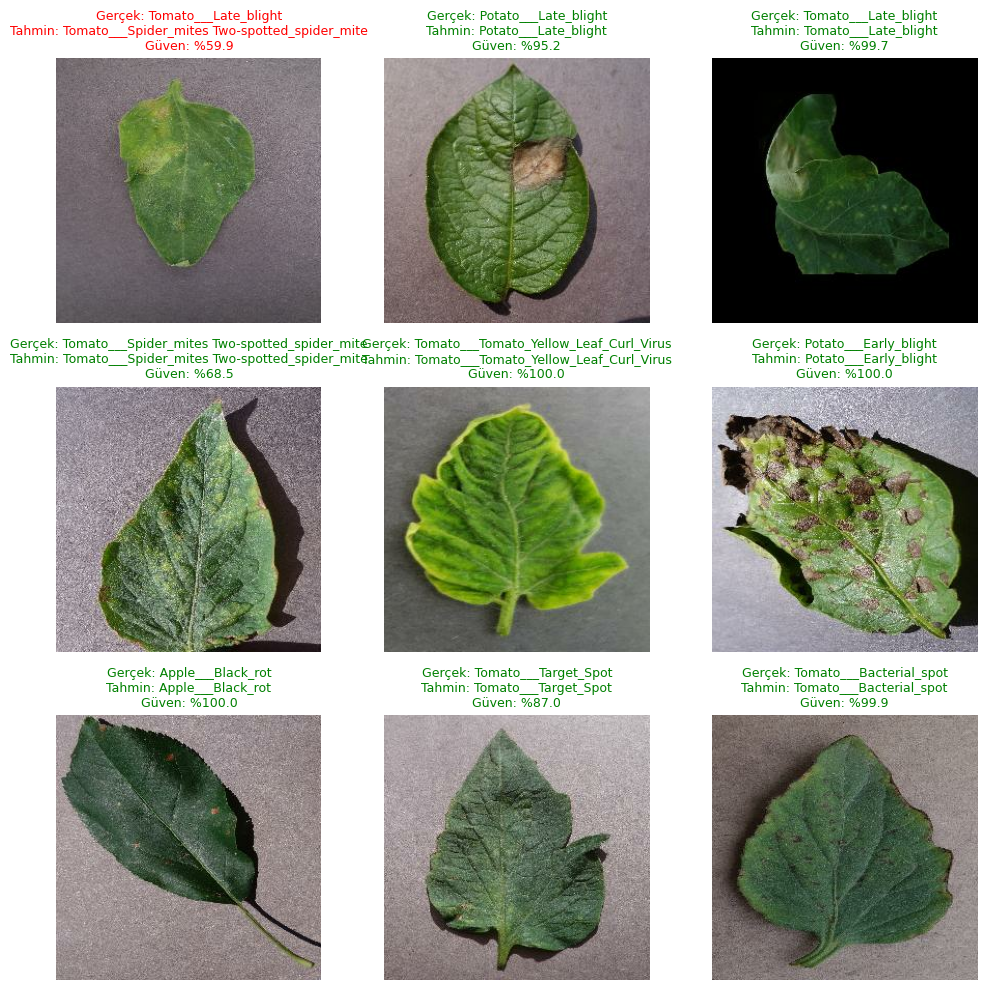

In [18]:
import numpy as np
import random
import matplotlib.pyplot as plt

# 1. Sınıf isimlerini güncel veri yükleyicinden almak
class_names = train_ds.class_names

# 2. Doğrulama setinden bir paket (batch) resim alma
image_batch, label_batch = next(iter(val_ds))

# 3. Modelin tahminlerini alma
predictions = model.predict(image_batch)

# 4. Rastgele 9 tane benzersiz indeks seçme
random_indices = random.sample(range(len(image_batch)), 9)

plt.figure(figsize=(10, 10))
for i, idx in enumerate(random_indices):
    ax = plt.subplot(3, 3, i + 1)

    # Resmi göster
    plt.imshow(image_batch[idx].numpy().astype("uint8"))

    actual_label = class_names[label_batch[idx]]
    predicted_label = class_names[np.argmax(predictions[idx])]
    confidence = 100 * np.max(predictions[idx])

    # Tahmin doğruysa yeşil, yanlışsa kırmızı başlık
    color = "green" if actual_label == predicted_label else "red"

    plt.title(f"Gerçek: {actual_label}\nTahmin: {predicted_label}\nGüven: %{confidence:.1f}",
              color=color, fontsize=9)

    plt.axis("off")

plt.tight_layout()
plt.show()

In [20]:
import shutil
import tensorflow as tf
import os

# --- 1. MODELİ KAYDETME  ---
model_adi_h5 = 'bitki_hastalik_modeli_v3_gurultulu.h5'
model_adi_keras = 'bitki_hastalik_modeli_v3_gurultulu.keras'

try:
    # Lambda katmanları için save_format belirtiyoruz
    model.save(model_adi_h5, save_format='h5')
    model.save(model_adi_keras)
    print(f"Model başarıyla kaydedildi! ✅")
except Exception as e:
    print("Tam model kaydında hata oluştu, ağırlıklar (weights) kaydediliyor...")
    model.save_weights('bitki_weights_v3.weights.h5')
    print("Ağırlıklar kaydedildi! ✅")

# --- 2. TFLITE DÖNÜŞTÜRME ---
print("TFLite dönüştürme başlıyor...")
converter = tf.lite.TFLiteConverter.from_keras_model(model)
# Lambda katmanları için izin
converter.target_spec.supported_ops = [
    tf.lite.OpsSet.TFLITE_BUILTINS,
    tf.lite.OpsSet.SELECT_TF_OPS
]
tflite_model = converter.convert()

tflite_dosya_adi = 'bitki_hastalik_modeli_v3_gurultulu.tflite'
with open(tflite_dosya_adi, 'wb') as f:
    f.write(tflite_model)
print(f"TFLite oluşturuldu! ✅")

# --- 3. LABELS VE DRIVE YEDEKLEME ---
with open('labels.txt', 'w') as f:
    for name in class_names:
        f.write(f"{name}\n")

drive_yolu = '/content/drive/MyDrive/Bitki_Projesi_V3/'
if not os.path.exists(drive_yolu):
    os.makedirs(drive_yolu)

# Dosyaları Drive'a taşıma
for dosya in [model_adi_h5, model_adi_keras, tflite_dosya_adi, 'labels.txt']:
    if os.path.exists(dosya):
        shutil.copy(dosya, drive_yolu + dosya)

print(f"\n🚀 Tüm dosyalar Drive'a yedeklendi!")

Tam model kaydında hata oluştu, ağırlıklar (weights) kaydediliyor...
Ağırlıklar kaydedildi! ✅
TFLite dönüştürme başlıyor...
Saved artifact at '/tmp/tmpai5f14il'. The following endpoints are available:

* Endpoint 'serve'
  args_0 (POSITIONAL_ONLY): TensorSpec(shape=(None, 256, 256, 3), dtype=tf.float32, name='keras_tensor')
Output Type:
  TensorSpec(shape=(None, 17), dtype=tf.float32, name=None)
Captures:
  138936229327504: TensorSpec(shape=(), dtype=tf.resource, name=None)
  138936229292240: TensorSpec(shape=(), dtype=tf.resource, name=None)
  138936229296272: TensorSpec(shape=(), dtype=tf.resource, name=None)
  138936229295888: TensorSpec(shape=(), dtype=tf.resource, name=None)
  138936229256592: TensorSpec(shape=(), dtype=tf.resource, name=None)
  138936229260816: TensorSpec(shape=(), dtype=tf.resource, name=None)
  138936229277584: TensorSpec(shape=(), dtype=tf.resource, name=None)
  138936229257744: TensorSpec(shape=(), dtype=tf.resource, name=None)
  138936229138256: TensorSpec(s